# 4) Joint inversion of field data using cross gradients

In this example, we jointly invert ERT and SRT data using cross gradients.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import pygimli.physics.traveltime as tt


data_ERT = pg.load("../ERT/AV_DD_2.dat")
data_SRT = pg.load("SRT_P2_coords.sgt")


In [2]:
data_SRT.sensors()[0]

RVector3: (0.0, 299.29, 0.0)

14/09/26 - 11:55:56 - pyGIMLi - INFO - Cache c:\Users\Nino Menzel\optimize_ERT\.venv\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (5.0s x 2): C:\Users\Nino Menzel\AppData\Roaming\pygimli\Cache\6098675527716154953


14/09/26 - 11:55:56 - pyGIMLi - INFO - Found 2 regions.
14/09/26 - 11:55:56 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


Mesh: Nodes: 2408 Cells: 4563 Boundaries: 6970


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>, None)

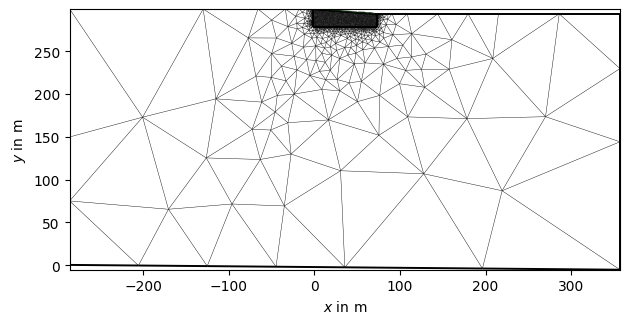

In [3]:
data_ERT["k"] = ert.createGeometricFactors(data_ERT, numerical=True)
data_ERT["rhoa"] = data_ERT["k"] * data_ERT["r"]

data_ERT["err"] = ert.estimateError(data_ERT, relativeError=0.0175, absoluteError=0.004)

mgr_ERT = ert.ERTManager(data_ERT)
plc = mt.createParaMeshPLC(data_ERT.sensorPositions(), paraDX=0.25, paraDepth=15, paraMaxCellSize=0.75)

mesh = mt.createMesh(plc)
mgr_ERT.setMesh(mesh)
print(mesh)
pg.show(mesh)

In [4]:
invArgs = dict(lam = 45, robustData=False, blockyModel=False, verbose=True)

inv = mgr_ERT.invert(**invArgs)

14/09/26 - 11:55:57 - pyGIMLi - INFO - Creating forward mesh from region infos.
14/09/26 - 11:55:57 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
14/09/26 - 11:55:57 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 9378 Cells: 18252 Boundaries: 13940
14/09/26 - 11:55:57 - pyGIMLi - INFO - Use median(data values)=145.18666371511696
14/09/26 - 11:55:57 - pyGIMLi - INFO - Created startmodel from forward operator:3651, min/max=145.186664/145.186664
14/09/26 - 11:55:57 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000015AD3236FC0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 20.48/759
min/max (error): 1.75%/1.77%
min/max (start model): 145/145
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  445.43
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   80.38 (dPhi = 81.59%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    6.15 (dPhi = 90.25%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    2.20 (dPhi = 51.34%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.18 (dPhi = 26.80%) lam: 45.0
-------------------------------------------------

(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x15ad3b0ab10>)

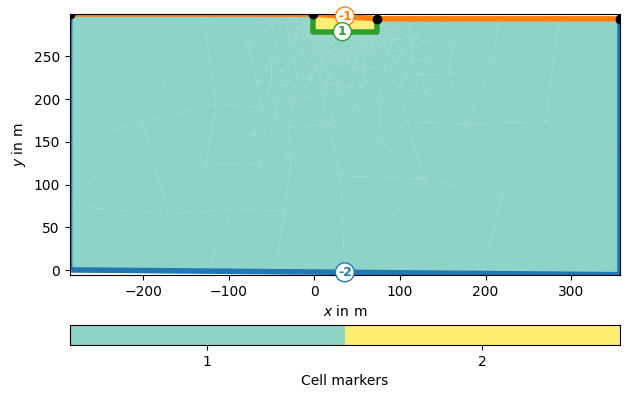

In [5]:
pg.show(mgr_ERT.mesh, markers=True)

In [6]:
meshSRT = mgr_ERT.paraDomain
for c in meshSRT.cells():
    c.setMarker(2)
mgr_SRT = tt.TravelTimeManager(data_SRT)
inv_SRT = mgr_SRT.invert(mesh=meshSRT,maxIter=20, verbose=True)

14/09/26 - 11:58:03 - pyGIMLi - INFO - Found 1 regions.
14/09/26 - 11:58:03 - pyGIMLi - INFO - Creating forward mesh from region infos.
14/09/26 - 11:58:03 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


14/09/26 - 11:58:03 - pyGIMLi - INFO - Create gradient starting model. 500: 5000
14/09/26 - 11:58:03 - pyGIMLi - INFO - Created startmodel from forward operator:3651, min/max=0.000200/0.002000
14/09/26 - 11:58:03 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x0000015AD386C130>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 0.0013/0.06
min/max (error): 3%/76.86%
min/max (start model): 2.0e-04/0.002
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  365.16
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  235.57 (dPhi = 35.41%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   34.97 (dPhi = 84.78%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.24 (dPhi = 92.76%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.08 (dPhi = 8.31%) lam: 20.0
-----------------------------------------------------------------

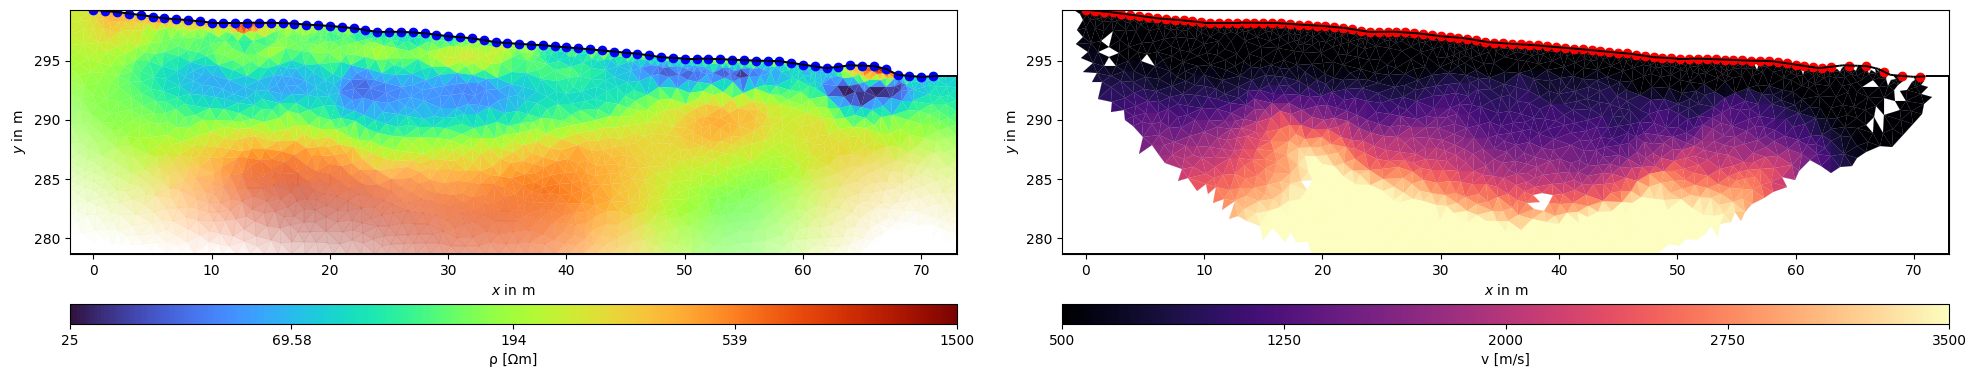

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
pg.show(mgr_ERT.paraDomain, data=inv, ax=ax1, label='ρ [Ωm]', cMap='turbo', cMin=25, cMax=1500,showMesh=False, logScale=True, coverage=mgr_ERT.coverage())
pg.show(mgr_SRT.paraDomain, data=inv_SRT, ax=ax2, label='v [m/s]', cMap='magma', cMin=500, cMax=3500, showMesh=False, coverage=mgr_SRT.standardizedCoverage())
ax1.scatter(data_ERT.sensors()[:,0], data_ERT.sensors()[:,2], color='blue')
ax2.scatter(data_SRT.sensors()[:,0], data_SRT.sensors()[:,1], color='red')

In [20]:
import jointtools.JItools as JI

crossfop = JI.crossGradient(
    fopList=[mgr_ERT.fop, mgr_SRT.fop], 
    dataList=[data_ERT['rhoa'], data_SRT['t']], 
    errorList=[data_ERT['err'], data_SRT['err']/data_SRT['t']], 
    meshList=[mesh, meshSRT],
    alpha = 0.5,
    smooth = False
    )

14/09/26 - 12:01:31 - pyGIMLi - INFO - Found 2 regions.
14/09/26 - 12:01:31 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
14/09/26 - 12:01:31 - pyGIMLi - INFO - Creating forward mesh from region infos.
14/09/26 - 12:01:31 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
14/09/26 - 12:01:31 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 9378 Cells: 18252 Boundaries: 13940
14/09/26 - 12:01:32 - pyGIMLi - INFO - Found 1 regions.
14/09/26 - 12:01:32 - pyGIMLi - INFO - Creating forward mesh from region infos.
14/09/26 - 12:01:32 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


In [23]:
dataVec = np.concatenate((np.array(data_ERT['rhoa']), np.array(data_SRT['t'])))
errorVec = np.concatenate((np.array(data_ERT['err']), np.array(data_SRT['err']/data_SRT['t'])))

14/09/26 - 12:02:22 - pyGIMLi - INFO - Use median(data values)=145.18666371511696
14/09/26 - 12:02:22 - pyGIMLi - INFO - Create gradient starting model. 500: 5000


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x15b3a01f950>)

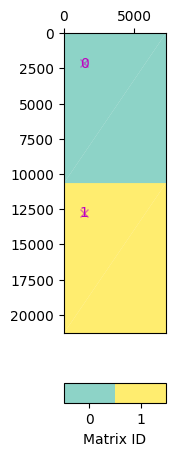

In [24]:
startmodel_ERT = mgr_ERT.fop.createStartModel(data_ERT['rhoa'])
startmodel_SRT = mgr_SRT.fop.createStartModel(data_SRT['t'])

startmodel = np.concatenate([startmodel_ERT,startmodel_SRT])

crossfop.createJacobian(startmodel)
pg.show(crossfop.constraints())

In [25]:
import pygimli.frameworks.inversion as inversion
inv = inversion.GaussNewtonInversion(fop=crossfop)
modelGN = inv.run(dataVals=dataVec, errorVals=errorVec, startModel=startmodel)
print(r'Final $\chi^2$ = ', inv.chi2())

dM:  7302 [0.43581008217716954,...,0.09258354699108384]
tau:  0.059500000000000004
dM:  7302 [0.2674165824436492,...,0.0926112108558625]
tau:  0.20800000000000002
dM:  7302 [-0.6613761490212076,...,0.10524153511056054]
tau:  0.8515
dM:  7302 [-0.7337291916786043,...,0.0927977724406903]
tau:  0.6535000000000001
dM:  7302 [0.07240452904975787,...,0.06633264941168808]
tau:  0.406
Final $\chi^2$ =  9.937816087036188


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x15b62b8b950>)

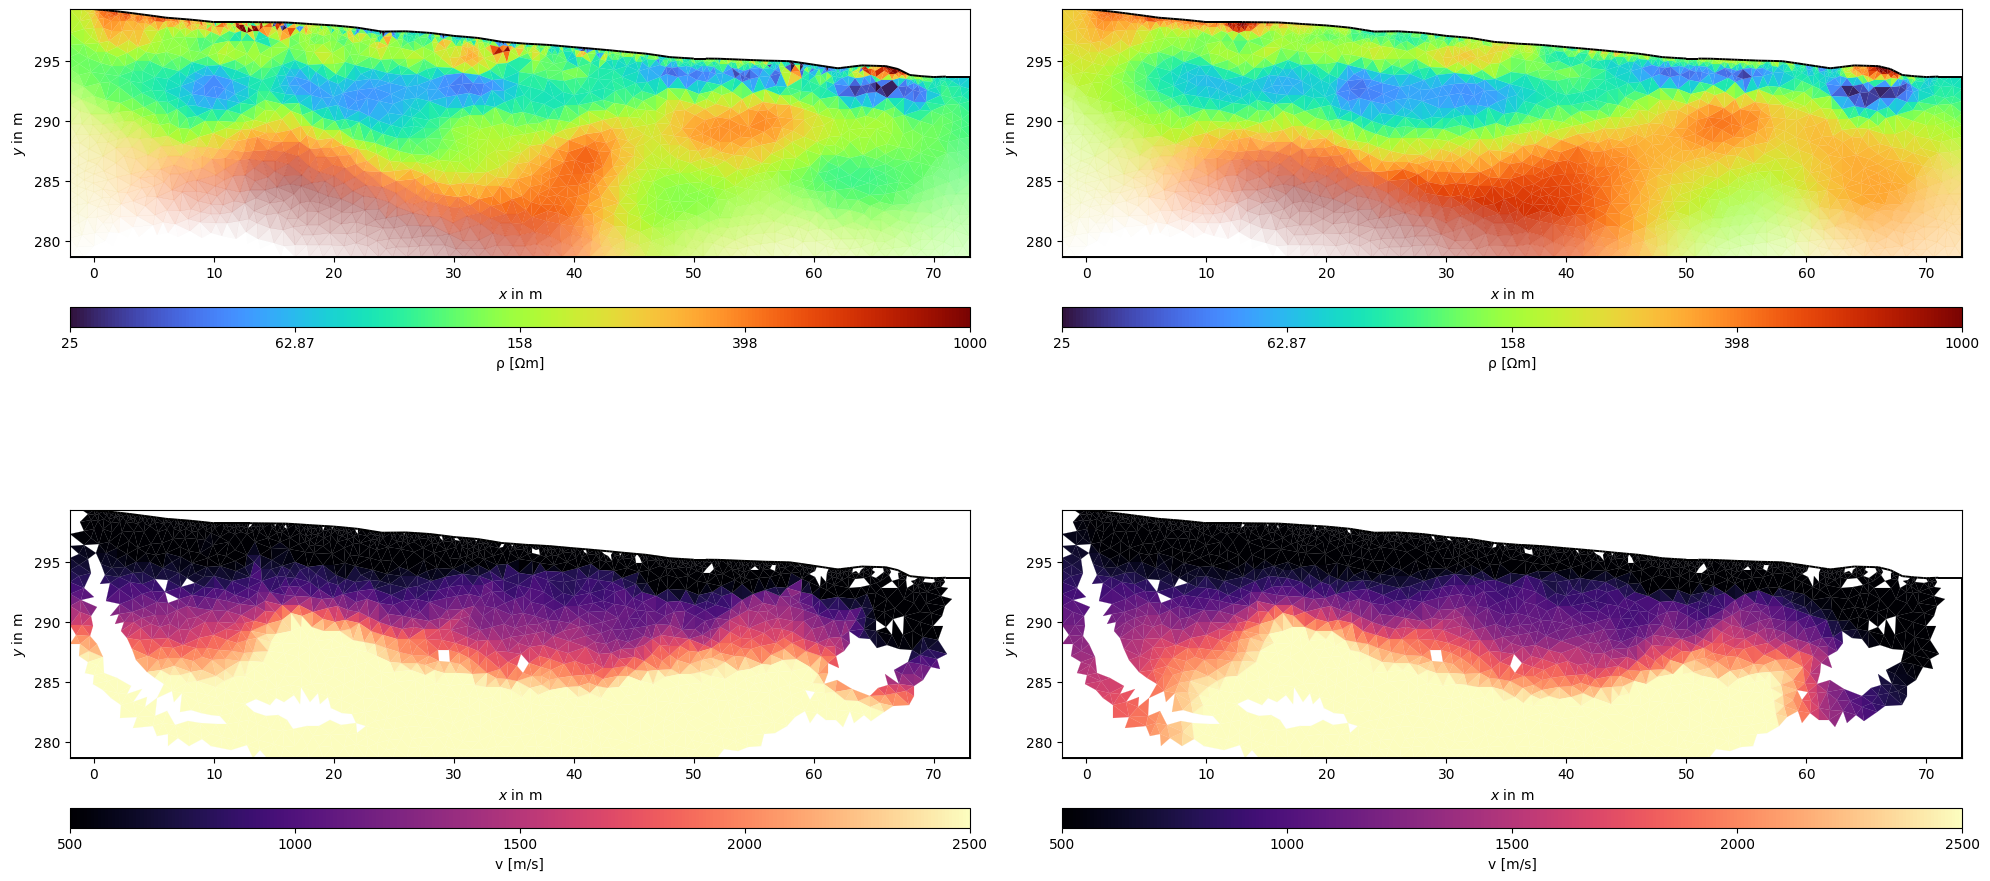

In [39]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2, 2, figsize=(20, 14))
pg.show(meshSRT, data=np.split(modelGN,2)[0], ax=ax1, cMap='turbo', cMin=25, cMax=1000, label='ρ [Ωm]', colorBar=True,  logScale=True, coverage=mgr_ERT.coverage())
pg.show(meshSRT, data=mgr_ERT.model, ax=ax2, cMap='turbo', cMin=25, cMax=1000, label='ρ [Ωm]', colorBar=True,  logScale=True, coverage=mgr_ERT.coverage())

pg.show(meshSRT, data=np.split(1/modelGN,2)[1], ax=ax3, cMap='magma', cMin=500, cMax=2500, label='v [m/s]', colorBar=True,  logScale=False, coverage=mgr_SRT.standardizedCoverage())
pg.show(meshSRT, data=mgr_SRT.model, ax=ax4, cMap='magma', cMin=500, cMax=2500, label='v [m/s]', colorBar=True,  logScale=False, coverage = mgr_SRT.standardizedCoverage())

(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x15b6d238350>)

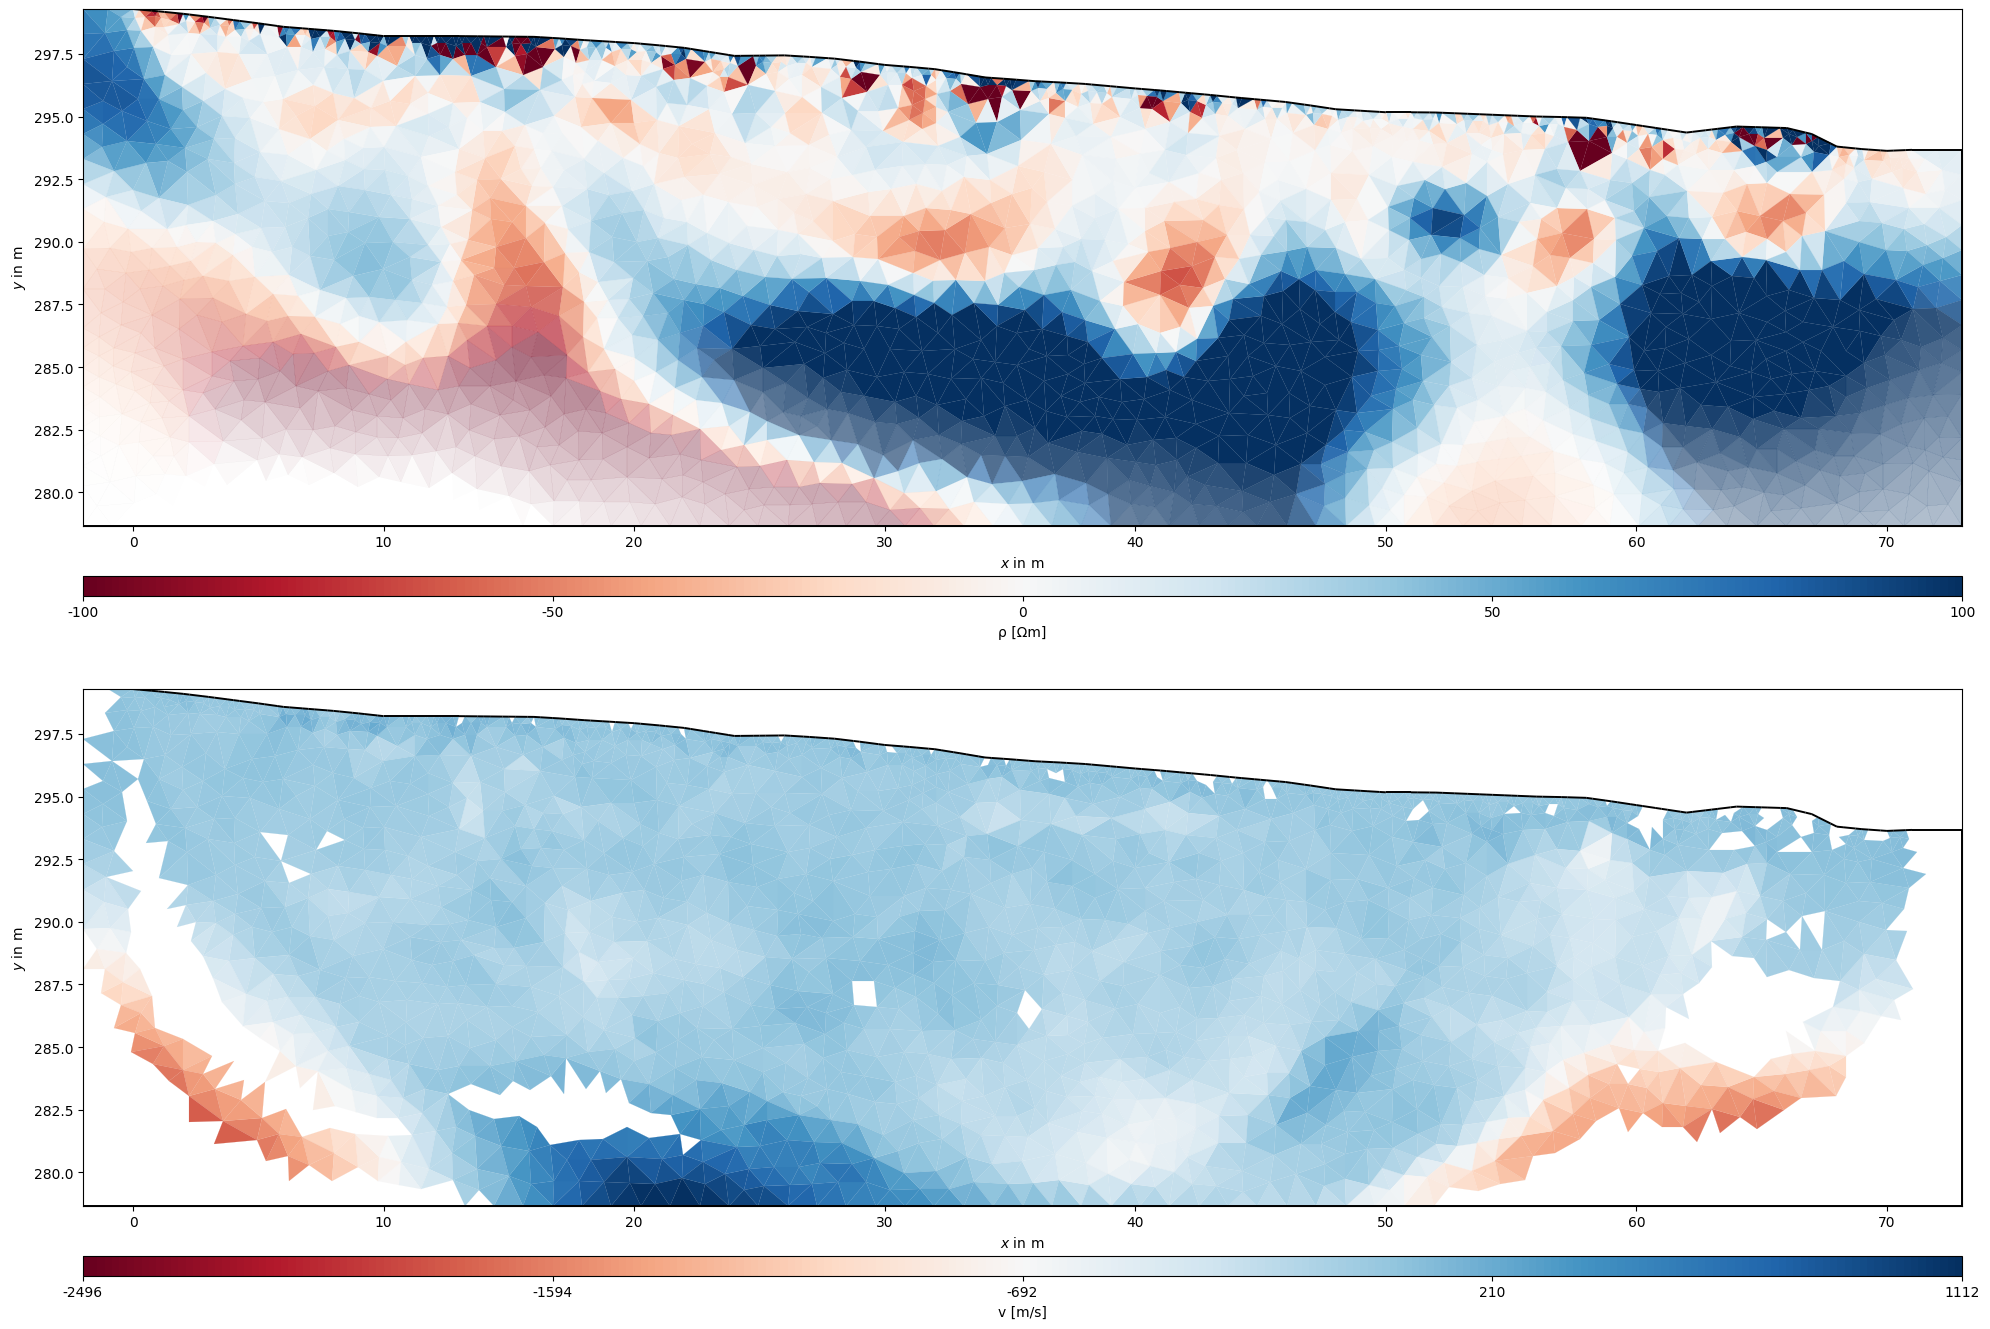

In [45]:
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(20, 14))

pg.show(meshSRT, data=(mgr_ERT.model-np.split(modelGN,2)[0]), ax=ax1, cMap='RdBu', label='ρ [Ωm]', colorBar=True, logScale=False, coverage=mgr_ERT.coverage(), cMin=-100, cMax=100)

pg.show(meshSRT, data=(mgr_SRT.model-np.split(1/modelGN,2)[1]), ax=ax2, cMap='RdBu', label='v [m/s]', colorBar=True,  logScale=False, coverage=mgr_SRT.standardizedCoverage())


In [41]:
mgr_ERT.model-np.split(modelGN,2)[0]

3651 [69.85955261245722,...,-112.30871042621447]